## CME AUG 2025

In [2]:
import pandas as pd
import numpy as np

cme_aug_2025 = pd.read_csv("../../data/raw/CME/CME_AUG_2025.csv")
cme_aug_2025 = cme_aug_2025.reset_index(drop = True)
cme_aug_2025["time"] = pd.to_datetime(cme_aug_2025["time"],unit="s") 

In [3]:
cme_aug_2025

,time,open,high,low,close,Volume
0,2025-03-02 23:00:00,96.0250,96.0250,96.015,96.015,100
1,2025-03-02 23:02:00,96.0100,96.0100,96.010,96.010,32
2,2025-03-02 23:04:00,96.0100,96.0100,96.010,96.010,3
3,2025-03-02 23:49:00,96.0050,96.0050,96.005,96.005,281
4,2025-03-02 23:50:00,96.0050,96.0050,96.005,96.005,17
...,...,...,...,...,...,...
30838,2025-08-01 20:55:00,95.6825,95.6825,95.680,95.680,482
30839,2025-08-01 20:56:00,95.6800,95.6800,95.680,95.680,12
30840,2025-08-01 20:57:00,95.6800,95.6800,95.680,95.680,23
30841,2025-08-01 20:58:00,95.6800,95.6800,95.680,95.680,121


## CME SEP 2025

In [4]:
cme_sep_2025 = pd.read_csv("../../data/raw/CME/CME_SEP_2025.csv")
cme_sep_2025 = cme_sep_2025.reset_index(drop = True)
cme_sep_2025["time"] = pd.to_datetime(cme_sep_2025["time"],unit="s") 

In [5]:
cme_sep_2025

,time,open,high,low,close,Volume
0,2025-05-01 05:12:00,96.165,96.165,96.165,96.165,197
1,2025-05-01 06:46:00,96.170,96.170,96.170,96.170,12
2,2025-05-01 06:48:00,96.170,96.170,96.170,96.170,3
3,2025-05-01 06:53:00,96.170,96.170,96.170,96.170,21
4,2025-05-01 07:00:00,96.170,96.170,96.170,96.170,12
...,...,...,...,...,...,...
16996,2025-09-30 18:00:00,95.775,95.775,95.775,95.775,300
16997,2025-09-30 18:20:00,95.775,95.775,95.775,95.775,300
16998,2025-09-30 20:38:00,95.775,95.775,95.775,95.775,2
16999,2025-09-30 20:57:00,95.775,95.775,95.775,95.775,706


## Merge and then calculate probabilities

In [6]:
aug = cme_aug_2025.copy()
aug["time"] = pd.to_datetime(aug["time"], unit="s")
aug = aug.sort_values("time").set_index("time")

aug = aug.add_suffix("_aug_2025")

sep = cme_sep_2025.copy()
sep["time"] = pd.to_datetime(sep["time"], unit="s")
sep = sep.sort_values("time").set_index("time")

sep = sep.add_suffix("_sep_2025")

aug_aligned = aug.reindex(sep.index, method="ffill")


final_df = pd.concat([sep, aug_aligned], axis=1)
final_df = final_df.reset_index()

In [7]:
final_df

,time,open_sep_2025,high_sep_2025,low_sep_2025,close_sep_2025,Volume_sep_2025,open_aug_2025,high_aug_2025,low_aug_2025,close_aug_2025,Volume_aug_2025
0,2025-05-01 05:12:00,96.165,96.165,96.165,96.165,197,96.07,96.07,96.07,96.07,6
1,2025-05-01 06:46:00,96.170,96.170,96.170,96.170,12,96.07,96.07,96.07,96.07,35
2,2025-05-01 06:48:00,96.170,96.170,96.170,96.170,3,96.07,96.07,96.07,96.07,6
3,2025-05-01 06:53:00,96.170,96.170,96.170,96.170,21,96.07,96.07,96.07,96.07,8
4,2025-05-01 07:00:00,96.170,96.170,96.170,96.170,12,96.07,96.07,96.07,96.07,30
...,...,...,...,...,...,...,...,...,...,...,...
16996,2025-09-30 18:00:00,95.775,95.775,95.775,95.775,300,95.68,95.68,95.68,95.68,94
16997,2025-09-30 18:20:00,95.775,95.775,95.775,95.775,300,95.68,95.68,95.68,95.68,94
16998,2025-09-30 20:38:00,95.775,95.775,95.775,95.775,2,95.68,95.68,95.68,95.68,94
16999,2025-09-30 20:57:00,95.775,95.775,95.775,95.775,706,95.68,95.68,95.68,95.68,94


## Calculating Implied Probabilities

In [8]:
meeting_day = 17
days_in_september = 30

N = meeting_day           
M = days_in_september - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_aug"] = 100 - final_df["close_aug_2025"]
imp_df["effr_avg_sep"] = 100 - final_df["close_sep_2025"]

imp_df["effr_end_aug"] = imp_df["effr_avg_aug"]
imp_df["effr_start_sep"] = imp_df["effr_end_aug"]
imp_df["volume"] = final_df["Volume_sep_2025"]


In [9]:
imp_df

,time,effr_avg_aug,effr_avg_sep,effr_end_aug,effr_start_sep,volume
0,2025-05-01 05:12:00,3.93,3.835,3.93,3.93,197
1,2025-05-01 06:46:00,3.93,3.830,3.93,3.93,12
2,2025-05-01 06:48:00,3.93,3.830,3.93,3.93,3
3,2025-05-01 06:53:00,3.93,3.830,3.93,3.93,21
4,2025-05-01 07:00:00,3.93,3.830,3.93,3.93,12
...,...,...,...,...,...,...
16996,2025-09-30 18:00:00,4.32,4.225,4.32,4.32,300
16997,2025-09-30 18:20:00,4.32,4.225,4.32,4.32,300
16998,2025-09-30 20:38:00,4.32,4.225,4.32,4.32,2
16999,2025-09-30 20:57:00,4.32,4.225,4.32,4.32,706


In [10]:
imp_df["effr_end_sep"] = (
    imp_df["effr_avg_sep"] - (N / (N + M)) * imp_df["effr_start_sep"]
) / (M / (N + M))

In [11]:
imp_df["delta_effr"] = imp_df["effr_end_sep"] - imp_df["effr_start_sep"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]


states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [12]:
imp_df

,time,effr_avg_aug,effr_avg_sep,effr_end_aug,effr_start_sep,volume,effr_end_sep,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-05-01 05:12:00,3.93,3.835,3.93,3.93,197,3.710769,-0.219231,-0.876923,-1.0,0.123077,0.0,0.0,0.0,0.876923,0.123077,0.0,0.0,0.0,0.0
1,2025-05-01 06:46:00,3.93,3.830,3.93,3.93,12,3.699231,-0.230769,-0.923077,-1.0,0.076923,0.0,0.0,0.0,0.923077,0.076923,0.0,0.0,0.0,0.0
2,2025-05-01 06:48:00,3.93,3.830,3.93,3.93,3,3.699231,-0.230769,-0.923077,-1.0,0.076923,0.0,0.0,0.0,0.923077,0.076923,0.0,0.0,0.0,0.0
3,2025-05-01 06:53:00,3.93,3.830,3.93,3.93,21,3.699231,-0.230769,-0.923077,-1.0,0.076923,0.0,0.0,0.0,0.923077,0.076923,0.0,0.0,0.0,0.0
4,2025-05-01 07:00:00,3.93,3.830,3.93,3.93,12,3.699231,-0.230769,-0.923077,-1.0,0.076923,0.0,0.0,0.0,0.923077,0.076923,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16996,2025-09-30 18:00:00,4.32,4.225,4.32,4.32,300,4.100769,-0.219231,-0.876923,-1.0,0.123077,0.0,0.0,0.0,0.876923,0.123077,0.0,0.0,0.0,0.0
16997,2025-09-30 18:20:00,4.32,4.225,4.32,4.32,300,4.100769,-0.219231,-0.876923,-1.0,0.123077,0.0,0.0,0.0,0.876923,0.123077,0.0,0.0,0.0,0.0
16998,2025-09-30 20:38:00,4.32,4.225,4.32,4.32,2,4.100769,-0.219231,-0.876923,-1.0,0.123077,0.0,0.0,0.0,0.876923,0.123077,0.0,0.0,0.0,0.0
16999,2025-09-30 20:57:00,4.32,4.225,4.32,4.32,706,4.100769,-0.219231,-0.876923,-1.0,0.123077,0.0,0.0,0.0,0.876923,0.123077,0.0,0.0,0.0,0.0


In [13]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

## Filtering Based on Announcement Time

In [14]:
fomc_2025_utc = {
    "January 2025": pd.Timestamp("2025-01-29 19:00:00", tz="UTC"),
    "March 2025": pd.Timestamp("2025-03-19 18:00:00", tz="UTC"),
    "May 2025": pd.Timestamp("2025-05-07 18:00:00", tz="UTC"),
    "June 2025": pd.Timestamp("2025-06-18 18:00:00", tz="UTC"),
    "July 2025": pd.Timestamp("2025-07-30 18:00:00", tz="UTC"),
    "September 2025": pd.Timestamp("2025-09-17 18:00:00", tz="UTC"),
    "October 2025": pd.Timestamp("2025-10-29 19:00:00", tz="UTC"),
    "December 2025": pd.Timestamp("2025-12-10 19:00:00", tz="UTC"),
}

In [15]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [16]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2025_utc)

## Export the Data as a CSV

In [17]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_SEP_2025.csv"
path = os.path.join(DATA_DIR, filename)
imp_df.to_csv(path,index=False)

## Visualization 

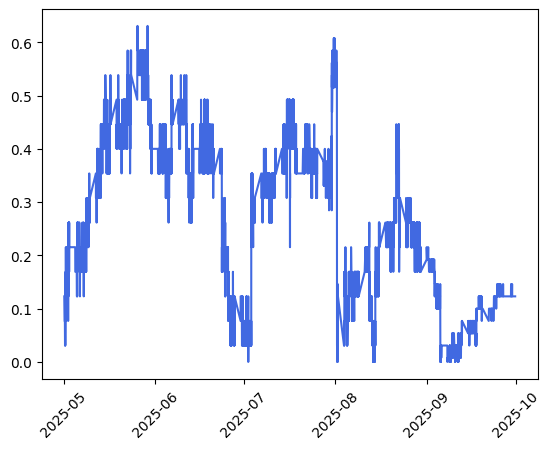

In [18]:
import matplotlib.pyplot as plt

plt.plot(imp_df["time"],imp_df['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()